0.002777777777777778


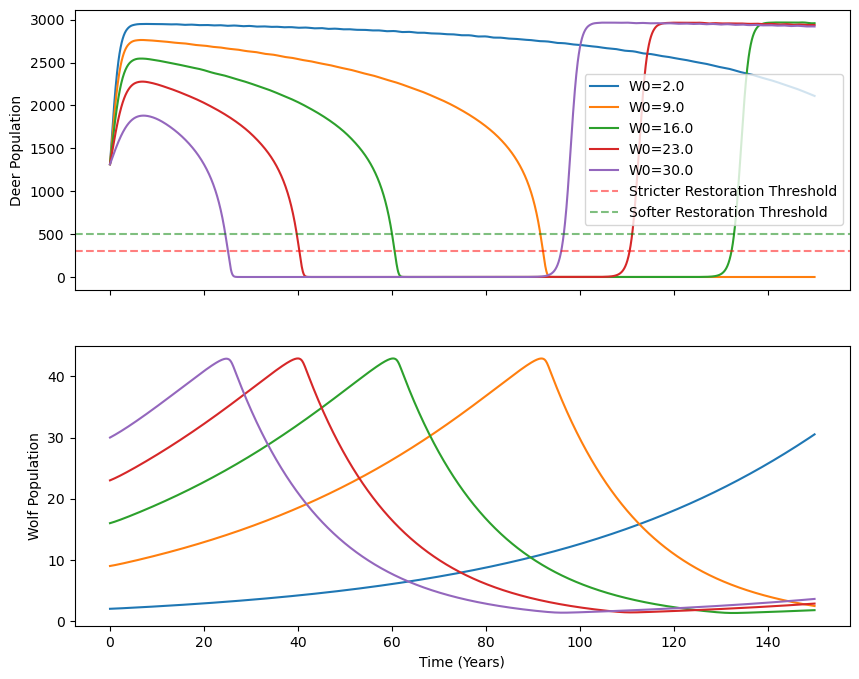

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ODE system with Holling Type II & Logistic Growth
def wolf_deer_holling(t, y, params):
    D, W = y
    r, e, beta, d, h, K = params
    
    # Holling Type II functional response
    predation = (e * D * W) / (1 + h * e * D)
    
    # Logistic growth for deer + predation
    dDdt = r * D * (1 - D/K) - predation
    
    # Wolf growth based on saturated consumption
    dWdt = beta * predation - d * W
    
    return [dDdt, dWdt]

def simulate_holling(params, D0, W0, t_max=150):
    t_eval = np.linspace(0, t_max, 2000)
    sol = solve_ivp(wolf_deer_holling, [0, t_max], [D0, W0], 
                    args=(params,), t_eval=t_eval, method='RK45')
    return sol.t, sol.y[0], sol.y[1]

# --- Parameters ---
# --- Parameters ---
D_star = 423 #  414
r = 1.138      # deer birth rate - death rate
h = 0.038       # handling time - NOT FULLY ACCURATE
e = -18/(18*h*D_star - D_star) #-18/(18*h*D_star - D_star)  # attack rate - want it to go up to improve dynamics 
d = 0.05       # wolf death rate
beta = (d*(1+h*e*D_star))/(e*D_star)   # conversion efficiency - independent of D_star (as expected) - want it to go up to improve dynamics
print(beta)

K = 3000      # deer carrying capacity
# as D_star goes down, model becomes more sensitive to handling time!

params = (r, e, beta, d, h, K)

# Initial populations
D0 = 1315
W0_values = np.linspace(2, 30, 5) 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for W0 in W0_values:
    t, D, W = simulate_holling(params, D0, W0)
    ax1.plot(t, D, label=f"W0={W0}")
    ax2.plot(t, W, label=f"W0={W0}")

ax1.axhline(300, color='red', linestyle='--', alpha=0.5, label="Stricter Restoration Threshold")
ax1.axhline(500, color='green', linestyle='--', alpha=0.5, label="Softer Restoration Threshold")
ax1.set_ylabel("Deer Population")
ax1.legend()
ax2.set_xlabel("Time (Years)")
ax2.set_ylabel("Wolf Population")
plt.show()

In [ ]:
# # --- Parameters --- OLD
# D_star = 414   #
# r = 1.138      # deer birth rate - death rate
# h = 0.03       # handling time 
# e = 0.18/D_star #-18/(18*h*D_star - D_star)  # attack rate - want it to go up to improve dynamics 
# print(e)
# print(18/D_star)
# d = 0.05       # wolf death rate
# beta = (d*(1+h*e*D_star))/(e*D_star)   # conversion efficiency - independent of D_star (as expected) - want it to go up to improve dynamics
# print(beta)
# K = 1700      # deer carrying capacity

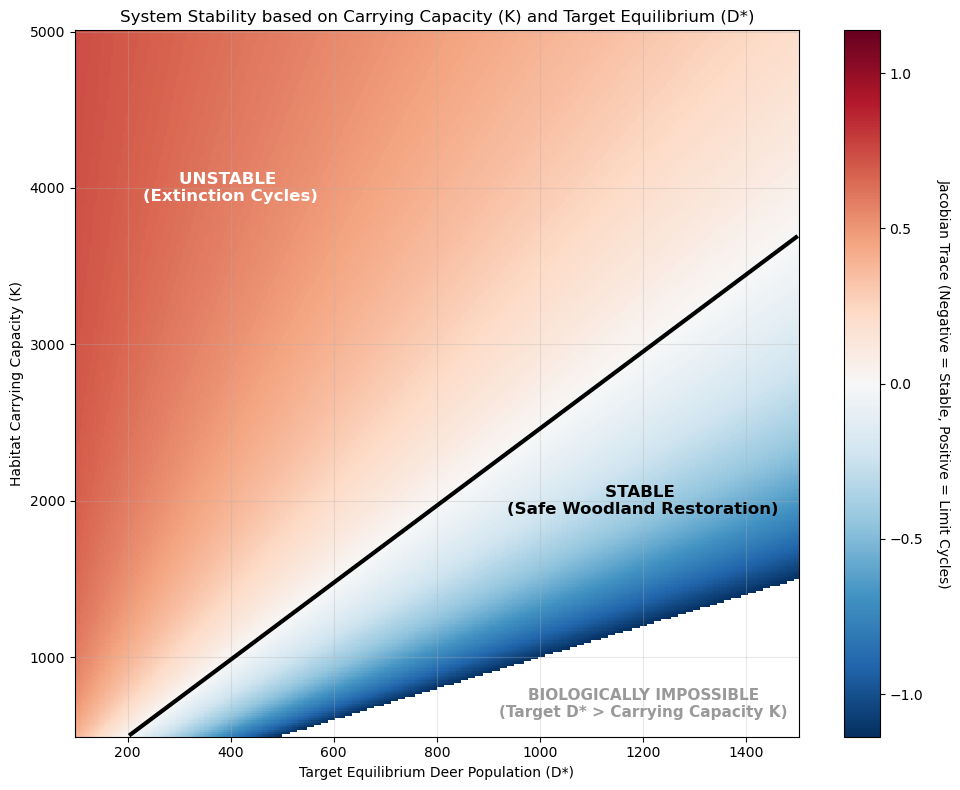

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# --- Fixed Parameters ---
r = 1.138      # deer birth rate - death rate
h = 0.038      # handling time
d = 0.05       # wolf death rate

# --- Parameter Sweep Ranges ---
# Sweeping D_star from 100 to 1500 deer
D_star_vals = np.linspace(100, 1500, 300) 

# Sweeping Carrying Capacity (K) from 500 to 5000 deer
K_vals = np.linspace(500, 5000, 300)

# Create a 2D grid for all combinations
D_grid, K_grid = np.meshgrid(D_star_vals, K_vals)

# --- The Math ---
# 1. Calculate 'e' dynamically for the entire grid
e_grid = -18 / (18 * h * D_grid - D_grid)

# 2. Calculate the Trace of the Jacobian for stability
trace_grid = r * (1 - 2 * D_grid / K_grid) - (r * (1 - D_grid / K_grid)) / (1 + h * e_grid * D_grid)

# 3. Mask invalid biological data
# We cannot have a target equilibrium (D*) higher than the environment's carrying capacity (K)
invalid_mask = D_grid >= K_grid
trace_grid = np.ma.masked_where(invalid_mask, trace_grid)

# --- Plotting the Heatmap ---
plt.figure(figsize=(10, 8))

# Plot the stability gradient (Blue = Stable, Red = Unstable)
# We center the colormap at 0 so the visual boundary perfectly matches the math
bound = np.nanmax(np.abs(trace_grid))
heatmap = plt.pcolormesh(D_grid, K_grid, trace_grid, cmap='RdBu_r', vmin=-bound, vmax=bound, shading='auto')

# Draw a thick black line exactly where Trace = 0 (The Bifurcation Boundary)
plt.contour(D_grid, K_grid, trace_grid, levels=[0], colors='black', linewidths=3)

# Formatting
cbar = plt.colorbar(heatmap)
cbar.set_label('Jacobian Trace (Negative = Stable, Positive = Limit Cycles)', rotation=270, labelpad=20)

# Add custom text annotations for the zones
plt.text(1200, 2000, "STABLE \n(Safe Woodland Restoration)", color='black', 
         fontsize=12, fontweight='bold', ha='center', va='center')
plt.text(400, 4000, "UNSTABLE \n(Extinction Cycles)", color='white', 
         fontsize=12, fontweight='bold', ha='center', va='center')
plt.text(1200, 700, "BIOLOGICALLY IMPOSSIBLE\n(Target D* > Carrying Capacity K)", color='gray', 
         fontsize=11, fontweight='bold', ha='center', va='center', alpha=0.8)


plt.title("System Stability based on Carrying Capacity (K) and Target Equilibrium (D*)")
plt.xlabel("Target Equilibrium Deer Population (D*)")
plt.ylabel("Habitat Carrying Capacity (K)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()